# Setup:

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO)

from src.data_loader import load_cmapss, add_rul_to_train, create_anomaly_labels, get_sensor_columns
from src.preprocessing import (
    remove_constant_sensors, normalize_global,
    train_test_split_by_unit
)
from src.feature_engineering import build_feature_pipeline
from src.models import IsolationForestDetector, AutoencoderDetector, OneClassSVMDetector
from src.evaluation import evaluate_model, compare_models

# Prepare data:

In [4]:
train_df, _, _ = load_cmapss('FD001')
train_df = add_rul_to_train(train_df)
train_df = create_anomaly_labels(train_df, threshold=30)
sensor_cols = get_sensor_columns(train_df)
train_df, kept_sensors = remove_constant_sensors(train_df, sensor_cols)

# Feature engineering
featured_df = build_feature_pipeline(train_df, kept_sensors,
    rolling_windows=[5, 10], lags=[1, 5], ewma_spans=[5])

# Split by engine unit
train_split, test_split = train_test_split_by_unit(featured_df, test_ratio=0.2)

# Get feature columns (exclude metadata)
exclude = ['unit_id', 'cycle', 'rul', 'anomaly']
feature_cols = [c for c in featured_df.columns if c not in exclude]

# Normalize
from src.preprocessing import normalize_global
train_split, scaler = normalize_global(train_split, feature_cols, method='standard')
test_split, _ = normalize_global(test_split, feature_cols, method='standard', scaler=scaler)

# Extract arrays
X_train = train_split[feature_cols].values
y_train = train_split['anomaly'].values
X_test = test_split[feature_cols].values
y_test = test_split['anomaly'].values

# Handle any NaN from feature engineering
X_train = np.nan_to_num(X_train, 0)
X_test = np.nan_to_num(X_test, 0)

print(f"Train: {X_train.shape}, anomaly rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, anomaly rate: {y_test.mean():.3f}")

INFO:src.data_loader:Loaded FD001: train=20631 rows, test=13096 rows, 100 engines
INFO:src.data_loader:Anomaly labels: 3100 anomalous (15.0%) out of 20631 samples
INFO:src.preprocessing:Dropped constant sensors: {'sensor_19', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_10'}
INFO:src.feature_engineering:Starting feature engineering pipeline...
INFO:src.feature_engineering:Added 60 rolling features
INFO:src.feature_engineering:Added 60 lag features
INFO:src.feature_engineering:Added 15 EWMA features
INFO:src.feature_engineering:Added 30 statistical features
INFO:src.feature_engineering:Final feature count: 188 columns
INFO:src.preprocessing:Split: 80 train units, 20 test units


Train: (16340, 184), anomaly rate: 0.152
Test:  (4291, 184), anomaly rate: 0.144


# Train Isolation Forest:

In [5]:
iso_forest = IsolationForestDetector(contamination=0.15, n_estimators=200)
iso_forest.fit(X_train)

iso_preds = iso_forest.predict(X_test)
iso_scores = iso_forest.score_samples(X_test)
iso_result = evaluate_model("Isolation Forest", y_test, iso_preds, iso_scores)

INFO:src.models.isolation_forest:Fitting Isolation Forest on 16340 samples...
C:\Users\anjan\Desktop\Goals\Projects\sensor-anomaly-detection\notebooks\..\src\evaluation.py:48: RuntimeWarning: invalid value encountered in divide
  2 * (precisions * recalls) / (precisions + recalls),
INFO:src.evaluation:Isolation Forest: P=0.507 R=0.555 F1=0.530 AUC-PR=0.447 AUC-ROC=0.873


# Train Autoencoder:

In [6]:
autoenc = AutoencoderDetector(
    input_dim=X_train.shape[1],
    encoding_dim=16,
    epochs=50,
    batch_size=256,
    threshold_percentile=85.0
)
autoenc.fit(X_train)

ae_preds = autoenc.predict(X_test)
ae_scores = autoenc.score_samples(X_test)
ae_result = evaluate_model("Autoencoder", y_test, ae_preds, ae_scores)

INFO:src.models.autoencoder:Training Autoencoder on 16340 samples, device=cpu
INFO:src.models.autoencoder:  Epoch 10/50, Loss: 0.528575
INFO:src.models.autoencoder:  Epoch 20/50, Loss: 0.503436
INFO:src.models.autoencoder:  Epoch 30/50, Loss: 0.496476
INFO:src.models.autoencoder:  Epoch 40/50, Loss: 0.490455
INFO:src.models.autoencoder:  Epoch 50/50, Loss: 0.485593
INFO:src.models.autoencoder:Threshold set at 85.0th percentile: 0.547612
C:\Users\anjan\Desktop\Goals\Projects\sensor-anomaly-detection\notebooks\..\src\evaluation.py:48: RuntimeWarning: invalid value encountered in divide
  2 * (precisions * recalls) / (precisions + recalls),
INFO:src.evaluation:Autoencoder: P=0.093 R=0.113 F1=0.102 AUC-PR=0.123 AUC-ROC=0.445


# Train One-Class SVM:

In [7]:
oc_svm = OneClassSVMDetector(nu=0.15)
oc_svm.fit(X_train)

svm_preds = oc_svm.predict(X_test)
svm_scores = oc_svm.score_samples(X_test)
svm_result = evaluate_model("One-Class SVM", y_test, svm_preds, svm_scores)

INFO:src.models.one_class_svm:Fitting One-Class SVM on 10000 samples...
C:\Users\anjan\Desktop\Goals\Projects\sensor-anomaly-detection\notebooks\..\src\evaluation.py:48: RuntimeWarning: invalid value encountered in divide
  2 * (precisions * recalls) / (precisions + recalls),
INFO:src.evaluation:One-Class SVM: P=0.257 R=0.279 F1=0.268 AUC-PR=0.230 AUC-ROC=0.707


# Compare all models:

In [8]:
results = [iso_result, ae_result, svm_result]
compare_models(results)

Model                      Precision     Recall         F1     AUC-PR    AUC-ROC
--------------------------------------------------------------------------------
Isolation Forest               0.507      0.555      0.530      0.447      0.873
One-Class SVM                  0.257      0.279      0.268      0.230      0.707
Autoencoder                    0.093      0.113      0.102      0.123      0.445


# Visualization: PR curves:

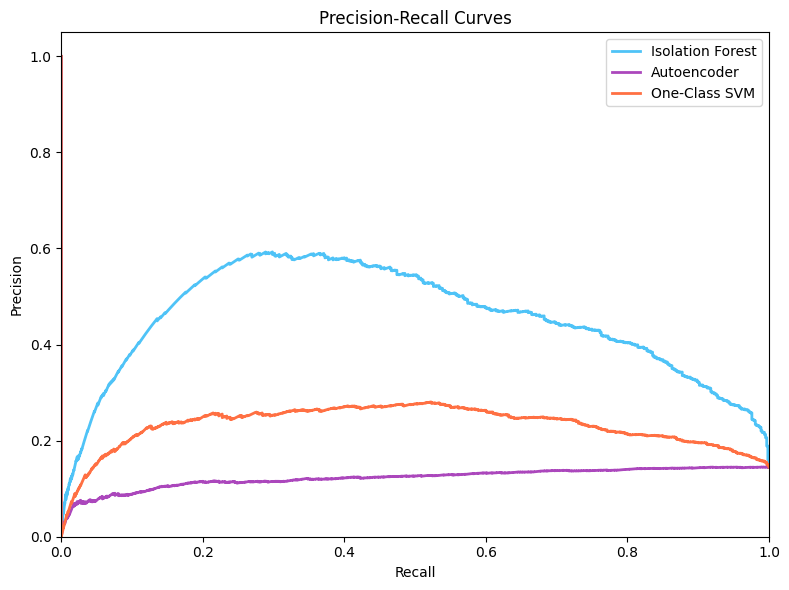

In [9]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, scores, color in [
    ("Isolation Forest", iso_scores, '#4fc3f7'),
    ("Autoencoder", ae_scores, '#ab47bc'),
    ("One-Class SVM", svm_scores, '#ff7043')
]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ax.plot(rec, prec, label=name, linewidth=2, color=color)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('../data/model_comparison_pr.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best model:

In [10]:
import os
os.makedirs('../models', exist_ok=True)

# Save all models
iso_forest.save('../models/isolation_forest.pkl')
autoenc.save('../models/autoencoder.pt')
oc_svm.save('../models/one_class_svm.pkl')
print("✅ All models saved!")

INFO:src.models.isolation_forest:Model saved to ../models/isolation_forest.pkl
INFO:src.models.autoencoder:Model saved to ../models/autoencoder.pt
INFO:src.models.one_class_svm:Model saved to ../models/one_class_svm.pkl


✅ All models saved!
